In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine learning
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

# Uncertainty quantification
from sklearn.ensemble import GradientBoostingRegressor

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')



In [3]:
# Load the final training dataset
train_final = pd.read_csv('/home/jupyter/train_final.csv')

# Define feature columns
feature_cols = [col for col in train_final.columns 
                if col not in ['cut', 'cutter', 'max_wear']]

print(f"Dataset shape: {train_final.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)
print(f"\nTarget: max_wear")
print(f"Wear range: {train_final['max_wear'].min():.1f} to {train_final['max_wear'].max():.1f}")

Dataset shape: (945, 15)

Feature columns (12):
['vib_x_std', 'vib_x_max', 'force_x_p2p', 'force_y_mean', 'force_x_max', 'vib_y_std', 'force_y_max', 'vib_x_kurtosis', 'vib_y_kurtosis', 'force_y_kurtosis', 'force_y_skewness', 'force_x_kurtosis']

Target: max_wear
Wear range: 31.4 to 234.7


In [4]:
#  leave one cutter out
def get_split(test_cutter, train_final, feature_cols):
    """
    Split data by cutter - train on 2 cutters, test on 1
    """
    train = train_final[train_final['cutter'] != test_cutter]
    test = train_final[train_final['cutter'] == test_cutter]
    
    X_train = train[feature_cols].values
    y_train = train['max_wear'].values
    
    X_test = test[feature_cols].values
    y_test = test['max_wear'].values
    
    return X_train, y_train, X_test, y_test

# Test the split
X_train, y_train, X_test, y_test = get_split('c1', train_final, feature_cols)
print(f"Training on c4+c6: {X_train.shape}")
print(f"Testing on c1: {X_test.shape}")

Training on c4+c6: (630, 12)
Testing on c1: (315, 12)


In [5]:
# Train and evaluate models using leave-one-cutter-out
def train_evaluate(test_cutter, train_final, feature_cols):
    
    X_train, y_train, X_test, y_test = get_split(test_cutter, train_final, feature_cols)
    
    # Scale features - important for Ridge regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        # Use scaled data for Ridge, unscaled for tree models
        if name == 'Ridge':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        results[name] = {
            'model': model,
            'scaler': scaler,
            'y_pred': y_pred,
            'mae': mae,
            'rmse': rmse
        }
        
        print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    
    return results

# Run for each cutter as test
print("=== Leave C1 Out ===")
results_c1 = train_evaluate('c1', train_final, feature_cols)

print("\n=== Leave C4 Out ===")
results_c4 = train_evaluate('c4', train_final, feature_cols)

print("\n=== Leave C6 Out ===")
results_c6 = train_evaluate('c6', train_final, feature_cols)

=== Leave C1 Out ===
Ridge - MAE: 23.86, RMSE: 26.12
RandomForest - MAE: 14.00, RMSE: 16.33
GradientBoosting - MAE: 16.36, RMSE: 18.74

=== Leave C4 Out ===
Ridge - MAE: 16.14, RMSE: 18.37
RandomForest - MAE: 14.80, RMSE: 18.37
GradientBoosting - MAE: 14.36, RMSE: 17.82

=== Leave C6 Out ===
Ridge - MAE: 32.30, RMSE: 38.34
RandomForest - MAE: 24.88, RMSE: 27.98
GradientBoosting - MAE: 22.75, RMSE: 26.21


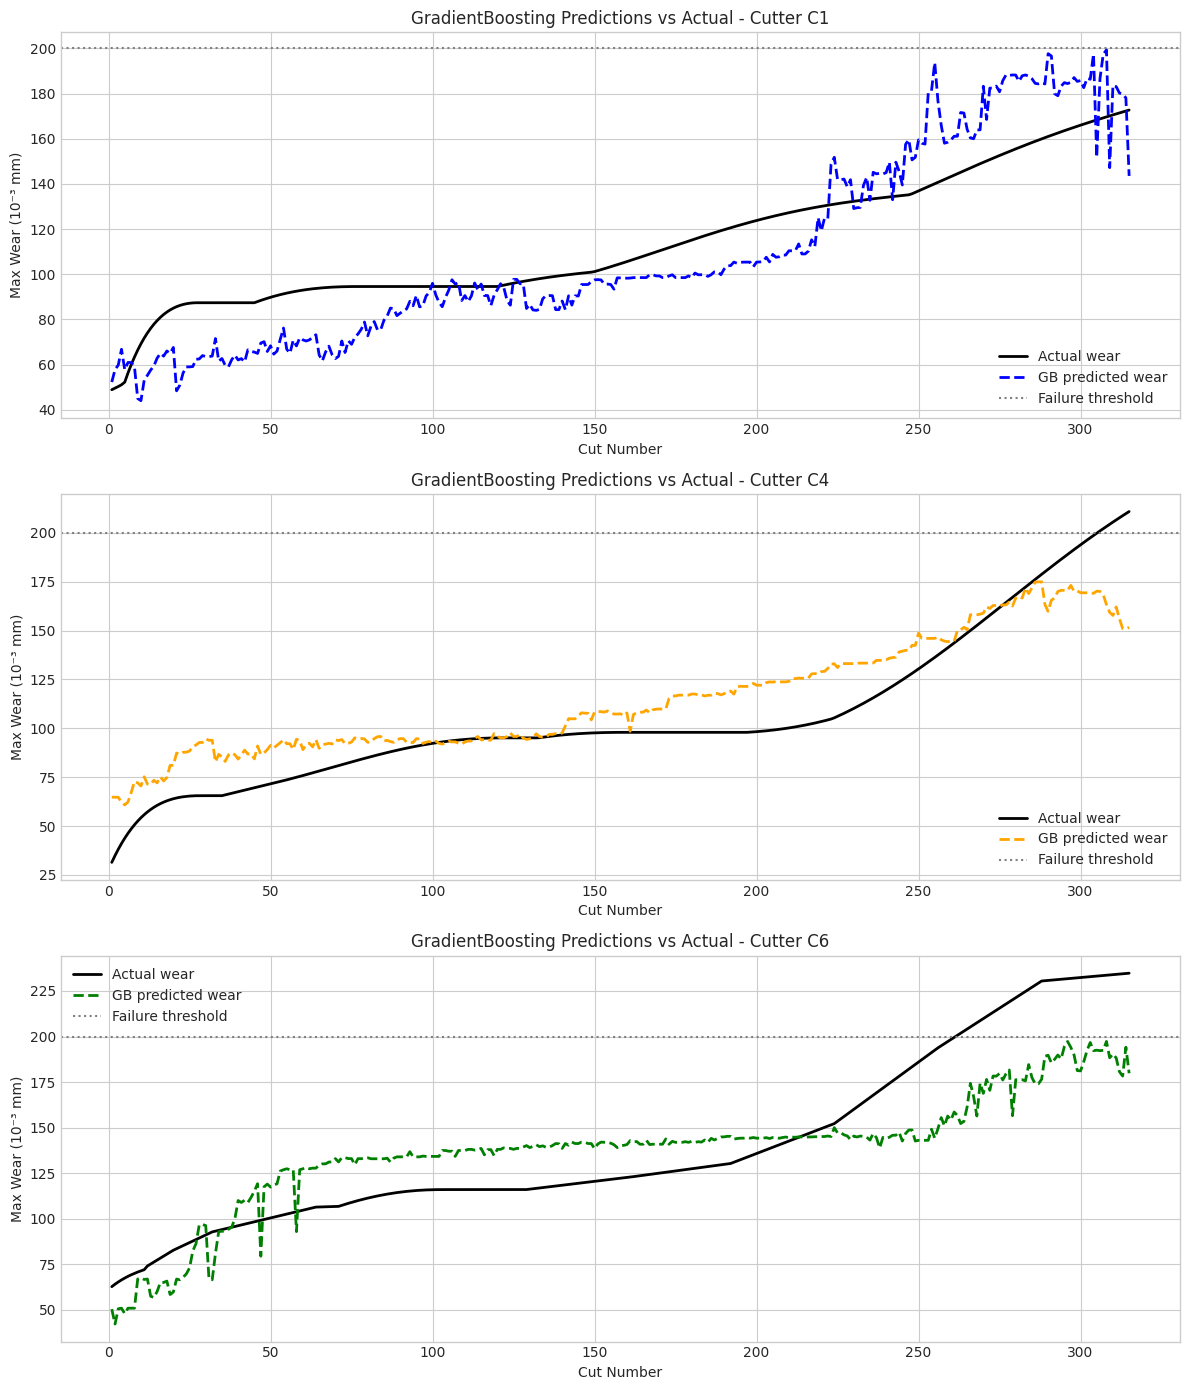

Plot saved


In [6]:
# Visualize GradientBoosting predictions vs actual for all three cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

cutters = ['c1', 'c4', 'c6']
results_list = [results_c1, results_c4, results_c6]
colors = {'c1': 'blue', 'c4': 'orange', 'c6': 'green'}

for ax, cutter, results in zip(axes, cutters, results_list):
    # Get actual wear
    test_data = train_final[train_final['cutter'] == cutter]
    y_actual = test_data['max_wear'].values
    y_pred = results['GradientBoosting']['y_pred']
    cuts = test_data['cut'].values
    
    ax.plot(cuts, y_actual, color='black', linewidth=2, label='Actual wear')
    ax.plot(cuts, y_pred, color=colors[cutter], linewidth=2, 
            linestyle='--', label='GB predicted wear')
    ax.axhline(y=200, color='gray', linestyle=':', label='Failure threshold')
    ax.set_title(f'GradientBoosting Predictions vs Actual - Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Max Wear (10⁻³ mm)')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/gb_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [8]:
from scipy.signal import savgol_filter

def smooth_predictions(y_pred, window=21, polyorder=3):
    """
    Apply Savitzky-Golay smoothing to predictions
    window: number of cuts to smooth over
    polyorder: polynomial order for smoothing
    """
    # Ensure monotonically increasing after smoothing
    smoothed = savgol_filter(y_pred, window_length=window, polyorder=polyorder)
    
    # Force monotonic increase - wear cannot decrease
    for i in range(1, len(smoothed)):
        if smoothed[i] < smoothed[i-1]:
            smoothed[i] = smoothed[i-1]
    
    return smoothed



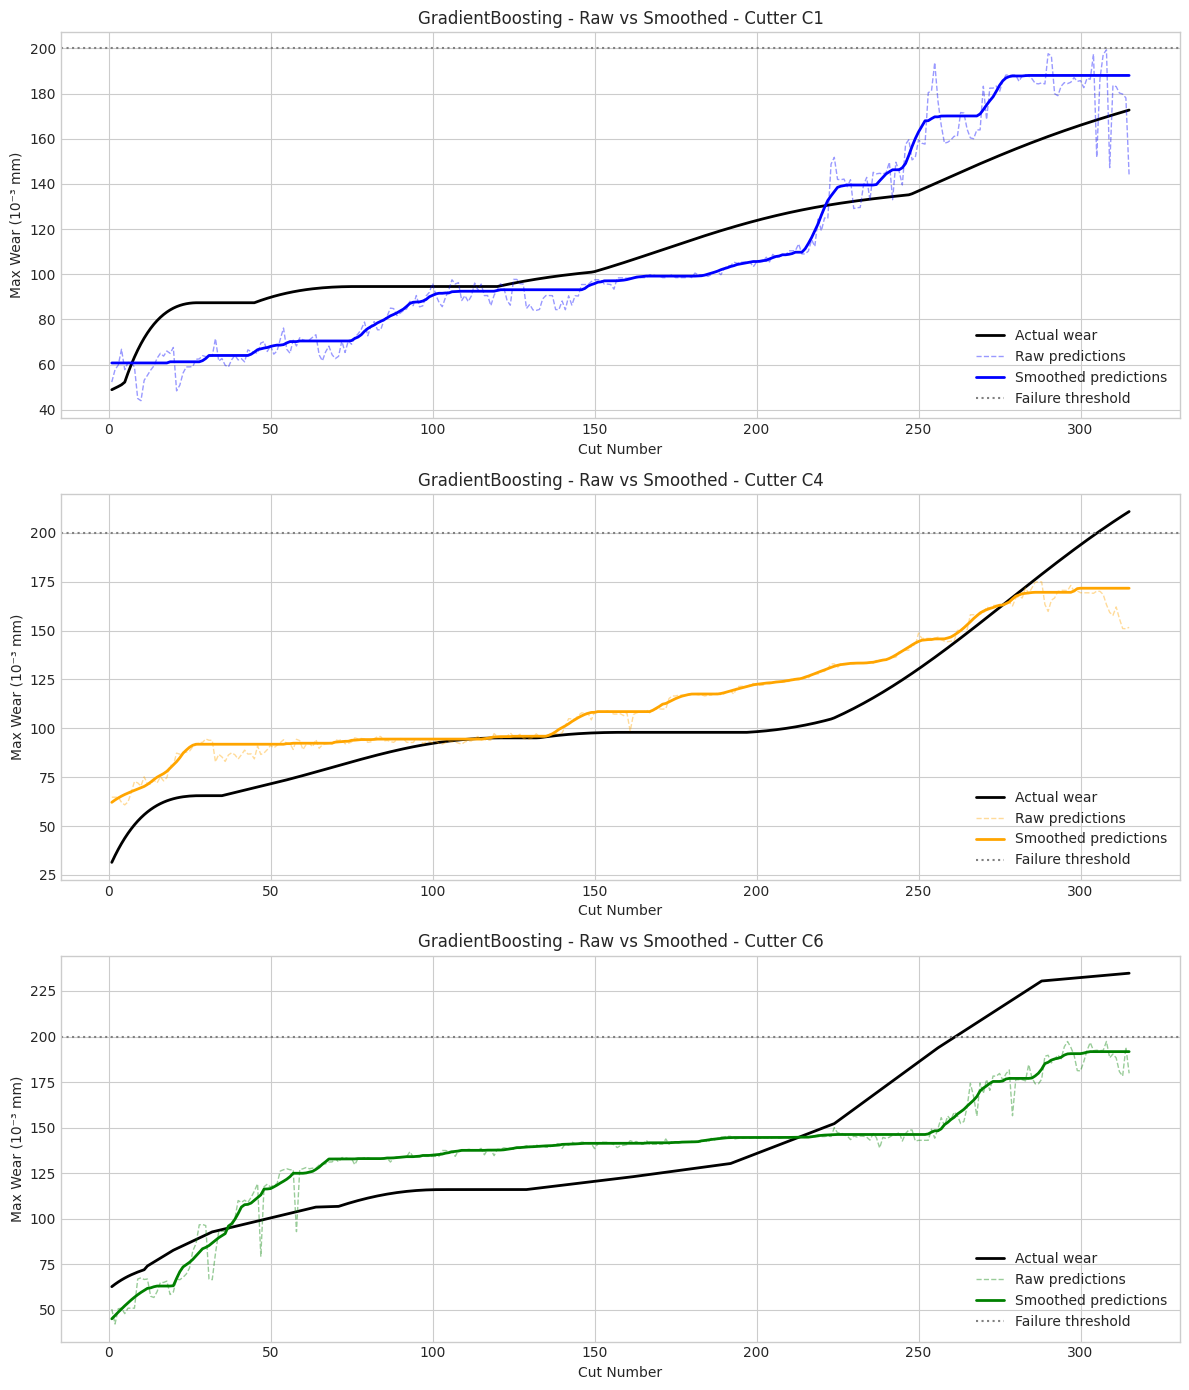

Plot saved


In [9]:
# Apply smoothing and visualize
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

cutters = ['c1', 'c4', 'c6']
results_list = [results_c1, results_c4, results_c6]
colors = {'c1': 'blue', 'c4': 'orange', 'c6': 'green'}

for ax, cutter, results in zip(axes, cutters, results_list):
    test_data = train_final[train_final['cutter'] == cutter]
    y_actual = test_data['max_wear'].values
    y_pred = results['GradientBoosting']['y_pred']
    y_smooth = smooth_predictions(y_pred)
    cuts = test_data['cut'].values
    
    ax.plot(cuts, y_actual, color='black', linewidth=2, label='Actual wear')
    ax.plot(cuts, y_pred, color=colors[cutter], linewidth=1, 
            linestyle='--', alpha=0.4, label='Raw predictions')
    ax.plot(cuts, y_smooth, color=colors[cutter], linewidth=2, 
            label='Smoothed predictions')
    ax.axhline(y=200, color='gray', linestyle=':', label='Failure threshold')
    ax.set_title(f'GradientBoosting - Raw vs Smoothed - Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Max Wear (10⁻³ mm)')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/gb_smoothed_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [10]:
# Quantile regression using GradientBoosting
# Train three models - lower bound (P10), median (P50), upper bound (P90)

def train_quantile_models(test_cutter, train_final, feature_cols):
    
    X_train, y_train, X_test, y_test = get_split(test_cutter, train_final, feature_cols)
    
    quantile_models = {}
    
    for quantile, label in [(0.10, 'P10'), (0.50, 'P50'), (0.90, 'P90')]:
        model = GradientBoostingRegressor(
            n_estimators=100,
            loss='quantile',
            alpha=quantile,
            random_state=42
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_smooth = smooth_predictions(y_pred)
        
        quantile_models[label] = {
            'model': model,
            'y_pred': y_pred,
            'y_smooth': y_smooth
        }
    
    return quantile_models, y_test

print("Training quantile models...")
qm_c1, y_test_c1 = train_quantile_models('c1', train_final, feature_cols)
qm_c4, y_test_c4 = train_quantile_models('c4', train_final, feature_cols)
qm_c6, y_test_c6 = train_quantile_models('c6', train_final, feature_cols)
print("Done")

Training quantile models...
Done


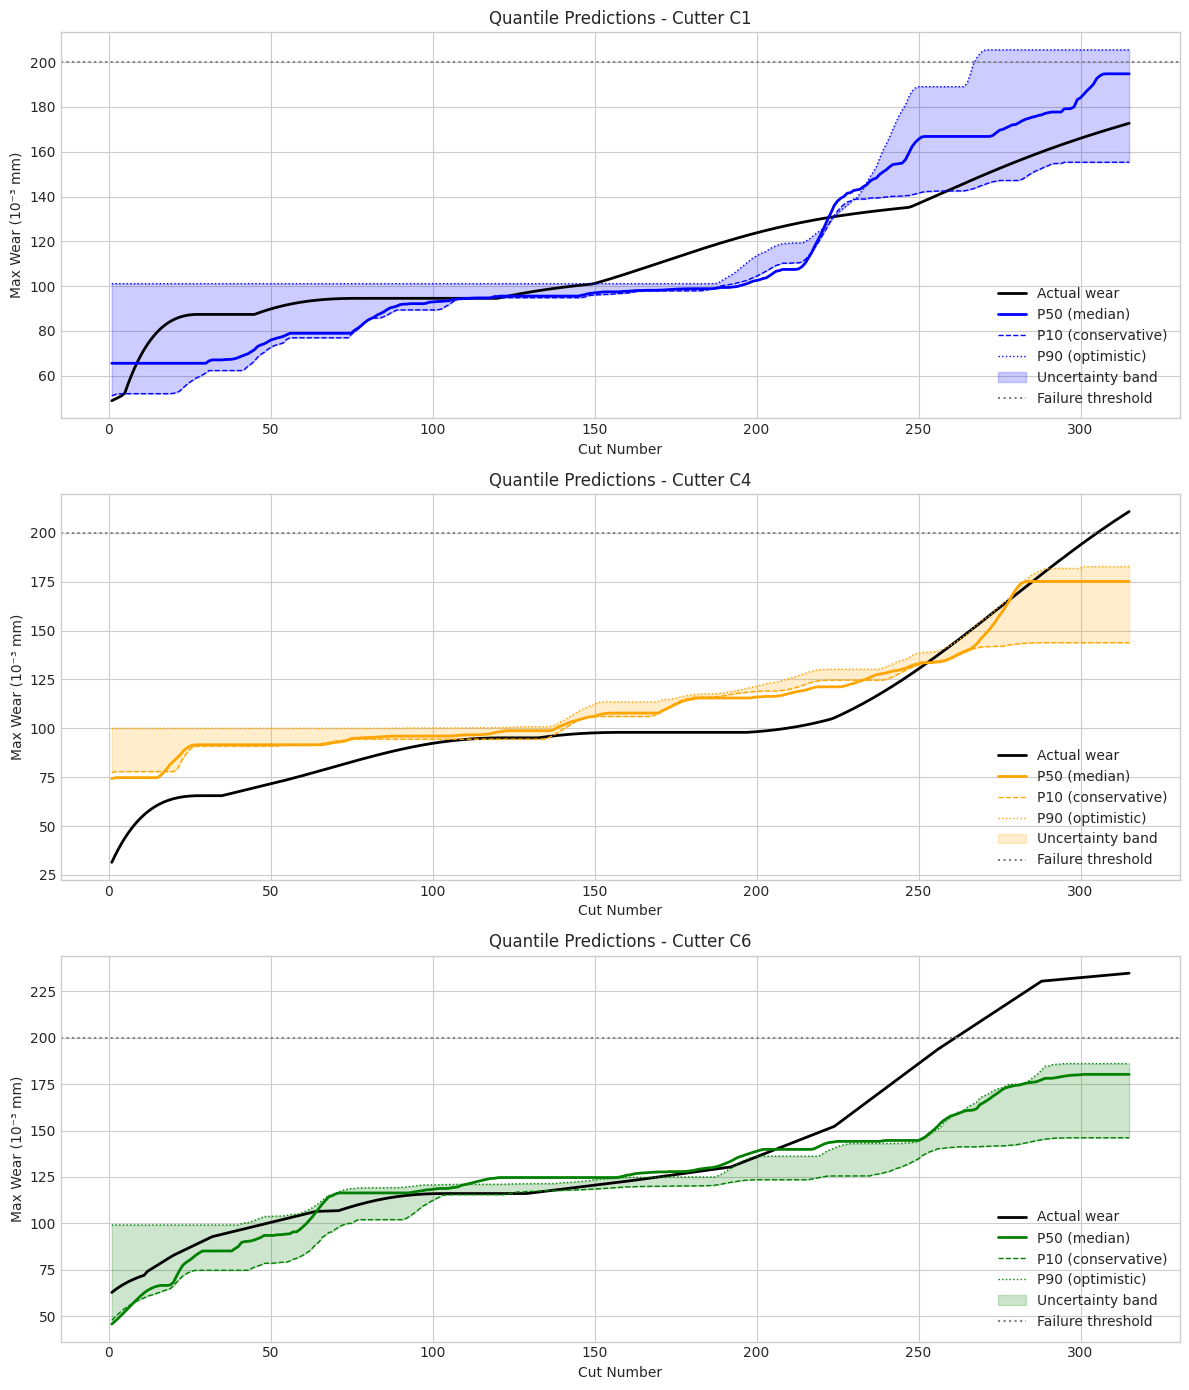

Plot saved


In [11]:
# Plot quantile predictions for all three cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

cutters = ['c1', 'c4', 'c6']
qm_list = [qm_c1, qm_c4, qm_c6]
y_test_list = [y_test_c1, y_test_c4, y_test_c6]
colors = {'c1': 'blue', 'c4': 'orange', 'c6': 'green'}

for ax, cutter, qm, y_test in zip(axes, cutters, qm_list, y_test_list):
    test_data = train_final[train_final['cutter'] == cutter]
    cuts = test_data['cut'].values
    
    p10 = qm['P10']['y_smooth']
    p50 = qm['P50']['y_smooth']
    p90 = qm['P90']['y_smooth']
    
    # Plot actual wear
    ax.plot(cuts, y_test, color='black', linewidth=2, label='Actual wear')
    
    # Plot quantile predictions
    ax.plot(cuts, p50, color=colors[cutter], linewidth=2, label='P50 (median)')
    ax.plot(cuts, p10, color=colors[cutter], linewidth=1, 
            linestyle='--', label='P10 (conservative)')
    ax.plot(cuts, p90, color=colors[cutter], linewidth=1,
            linestyle=':', label='P90 (optimistic)')
    
    # Shade uncertainty band
    ax.fill_between(cuts, p10, p90, alpha=0.2, 
                    color=colors[cutter], label='Uncertainty band')
    
    ax.axhline(y=200, color='gray', linestyle=':', label='Failure threshold')
    ax.set_title(f'Quantile Predictions - Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Max Wear (10⁻³ mm)')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/quantile_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [13]:
# Use P10 predictions to answer challenge question
# For each wear threshold W, find cut where predicted wear first crosses W

def predict_safe_cuts(y_smooth, cuts, wear_thresholds):
    """
    Given smoothed wear predictions, find cut number 
    where wear first crosses each threshold
    """
    predictions = []
    for W in wear_thresholds:
        # Find first cut where predicted wear exceeds W
        crossing = np.where(y_smooth >= W)[0]
        if len(crossing) > 0:
            cut_estimate = cuts[crossing[0]]
        else:
            # If never crosses, extrapolate beyond last cut
            cut_estimate = cuts[-1] + 10
        predictions.append(cut_estimate)
    return np.array(predictions)

wear_thresholds = np.arange(66, 166)

# Get actual safe cuts from wear files
def get_actual_safe_cuts(wear_df, wear_thresholds):
    actual = []
    for W in wear_thresholds:
        crossing = np.where(wear_df['max_wear'].values >= W)[0]
        if len(crossing) > 0:
            actual.append(wear_df['cut'].values[crossing[0]])
        else:
            actual.append(wear_df['cut'].values[-1] + 10)
    return np.array(actual)

# Load wear data
wear_c1 = pd.read_csv('/home/jupyter/milling/c1/c1_wear.csv',
                       header=0, names=['cut','flute_1','flute_2','flute_3'])
wear_c4 = pd.read_csv('/home/jupyter/milling/c4/c4_wear.csv',
                       header=0, names=['cut','flute_1','flute_2','flute_3'])
wear_c6 = pd.read_csv('/home/jupyter/milling/c6/c6_wear.csv',
                       header=0, names=['cut','flute_1','flute_2','flute_3'])

for wear_df in [wear_c1, wear_c4, wear_c6]:
    for col in ['cut','flute_1','flute_2','flute_3']:
        wear_df[col] = pd.to_numeric(wear_df[col], errors='coerce')
    wear_df['max_wear'] = wear_df[['flute_1','flute_2','flute_3']].max(axis=1)

print("Computing challenge predictions vs actual...")

# C1
cuts_c1 = train_final[train_final['cutter']=='c1']['cut'].values
pred_c1 = predict_safe_cuts(qm_c1['P10']['y_smooth'], cuts_c1, wear_thresholds)
actual_c1 = get_actual_safe_cuts(wear_c1, wear_thresholds)

# C4
cuts_c4 = train_final[train_final['cutter']=='c4']['cut'].values
pred_c4 = predict_safe_cuts(qm_c4['P10']['y_smooth'], cuts_c4, wear_thresholds)
actual_c4 = get_actual_safe_cuts(wear_c4, wear_thresholds)

# C6
cuts_c6 = train_final[train_final['cutter']=='c6']['cut'].values
pred_c6 = predict_safe_cuts(qm_c6['P10']['y_smooth'], cuts_c6, wear_thresholds)
actual_c6 = get_actual_safe_cuts(wear_c6, wear_thresholds)



Computing challenge predictions vs actual...


In [14]:
# Compute challenge scoring function
def challenge_score(estimated, actual):
    """
    PHM 2010 asymmetric scoring function
    Underestimate (d<0): exp(-d/10) - 1  → light penalty
    Overestimate (d>=0): exp(d/4.5) - 1  → heavy penalty
    """
    d = estimated - actual
    score = np.where(d < 0, 
                     np.exp(-d / 10) - 1,   # underestimate
                     np.exp(d / 4.5) - 1)   # overestimate
    return score

# Compute scores
score_c1 = challenge_score(pred_c1, actual_c1)
score_c4 = challenge_score(pred_c4, actual_c4)
score_c6 = challenge_score(pred_c6, actual_c6)

print("=== Challenge Scores (lower is better) ===")
print(f"C1 total score: {score_c1.sum():.2f}, mean: {score_c1.mean():.2f}")
print(f"C4 total score: {score_c4.sum():.2f}, mean: {score_c4.mean():.2f}")
print(f"C6 total score: {score_c6.sum():.2f}, mean: {score_c6.mean():.2f}")
print(f"\nOverall total score: {(score_c1.sum() + score_c4.sum() + score_c6.sum()):.2f}")

# Check how many thresholds we overestimated vs underestimated
for cutter, pred, actual in [('C1', pred_c1, actual_c1), 
                               ('C4', pred_c4, actual_c4),
                               ('C6', pred_c6, actual_c6)]:
    d = pred - actual
    over = (d >= 0).sum()
    under = (d < 0).sum()
    print(f"\n{cutter}: Overestimated {over} thresholds, Underestimated {under} thresholds")

=== Challenge Scores (lower is better) ===
C1 total score: 9357638.19, mean: 93576.38
C4 total score: 7738436.04, mean: 77384.36
C6 total score: 109853828865.71, mean: 1098538288.66

Overall total score: 109870924939.93

C1: Overestimated 89 thresholds, Underestimated 11 thresholds

C4: Overestimated 34 thresholds, Underestimated 66 thresholds

C6: Overestimated 99 thresholds, Underestimated 1 thresholds


In [15]:
# Retrain final model on ALL training data (c1 + c4 + c6)
X_all = train_final[feature_cols].values
y_all = train_final['max_wear'].values

# Train final GB model
final_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
final_gb.fit(X_all, y_all)

# Train quantile models on all data
final_quantile_models = {}
for quantile, label in [(0.10, 'P10'), (0.50, 'P50'), (0.90, 'P90')]:
    model = GradientBoostingRegressor(
        n_estimators=100,
        loss='quantile',
        alpha=quantile,
        random_state=42
    )
    model.fit(X_all, y_all)
    final_quantile_models[label] = model

print("Final models trained on all training data")
print(f"Training samples: {X_all.shape[0]}")
print(f"Features: {X_all.shape[1]}")

Final models trained on all training data
Training samples: 945
Features: 12


In [16]:
# Extract features from test cutters
import gcsfs
from scipy import stats

fs = gcsfs.GCSFileSystem()
bucket_path = "phm2010-data-temilola/milling"

def extract_features(filepath):
    df = pd.read_csv(filepath, header=None,
                     names=['force_x', 'force_y', 'force_z',
                            'vib_x', 'vib_y', 'vib_z', 'ae_rms'])
    features = {}
    for col in df.columns:
        signal = df[col].values
        features[f'{col}_mean']     = np.mean(signal)
        features[f'{col}_std']      = np.std(signal)
        features[f'{col}_rms']      = np.sqrt(np.mean(signal**2))
        features[f'{col}_kurtosis'] = stats.kurtosis(signal)
        features[f'{col}_skewness'] = stats.skew(signal)
        features[f'{col}_max']      = np.max(signal)
        features[f'{col}_p2p']      = np.max(signal) - np.min(signal)
    return features

def process_test_cutter(cutter_id, bucket_path, fs):
    print(f"\nProcessing test cutter {cutter_id}...")
    sensor_files = fs.ls(f"{bucket_path}/{cutter_id}/{cutter_id}")
    print(f"Found {len(sensor_files)} sensor files")
    
    all_features = []
    for filepath in sorted(sensor_files):
        filename = filepath.split('/')[-1]
        cut_num = int(filename.split('_')[-1].replace('.csv', ''))
        features = extract_features(f"gcs://{filepath}")
        features['cut'] = cut_num
        features['cutter'] = cutter_id
        all_features.append(features)
    
    return pd.DataFrame(all_features)

# Process all test cutters
test_c2 = process_test_cutter('c2', bucket_path, fs)
test_c3 = process_test_cutter('c3', bucket_path, fs)
test_c5 = process_test_cutter('c5', bucket_path, fs)

print(f"\nC2 shape: {test_c2.shape}")
print(f"C3 shape: {test_c3.shape}")
print(f"C5 shape: {test_c5.shape}")


Processing test cutter c2...
Found 315 sensor files

Processing test cutter c3...
Found 315 sensor files

Processing test cutter c5...
Found 315 sensor files

C2 shape: (315, 51)
C3 shape: (315, 51)
C5 shape: (315, 51)


In [17]:
# Predict wear for test cutters
def predict_test_cutter(test_df, final_quantile_models, feature_cols):
    X_test = test_df[feature_cols].values
    cuts = test_df['cut'].values
    
    predictions = {}
    for label, model in final_quantile_models.items():
        y_pred = model.predict(X_test)
        y_smooth = smooth_predictions(y_pred)
        predictions[label] = y_smooth
    
    return cuts, predictions

# Predict for each test cutter
cuts_c2, pred_c2 = predict_test_cutter(test_c2, final_quantile_models, feature_cols)
cuts_c3, pred_c3 = predict_test_cutter(test_c3, final_quantile_models, feature_cols)
cuts_c5, pred_c5 = predict_test_cutter(test_c5, final_quantile_models, feature_cols)

print("Wear predictions complete for test cutters")
print(f"\nC2 predicted wear range: {pred_c2['P50'].min():.1f} to {pred_c2['P50'].max():.1f}")
print(f"C3 predicted wear range: {pred_c3['P50'].min():.1f} to {pred_c3['P50'].max():.1f}")
print(f"C5 predicted wear range: {pred_c5['P50'].min():.1f} to {pred_c5['P50'].max():.1f}")

Wear predictions complete for test cutters

C2 predicted wear range: 50.4 to 203.8
C3 predicted wear range: 41.2 to 182.5
C5 predicted wear range: 42.3 to 186.3


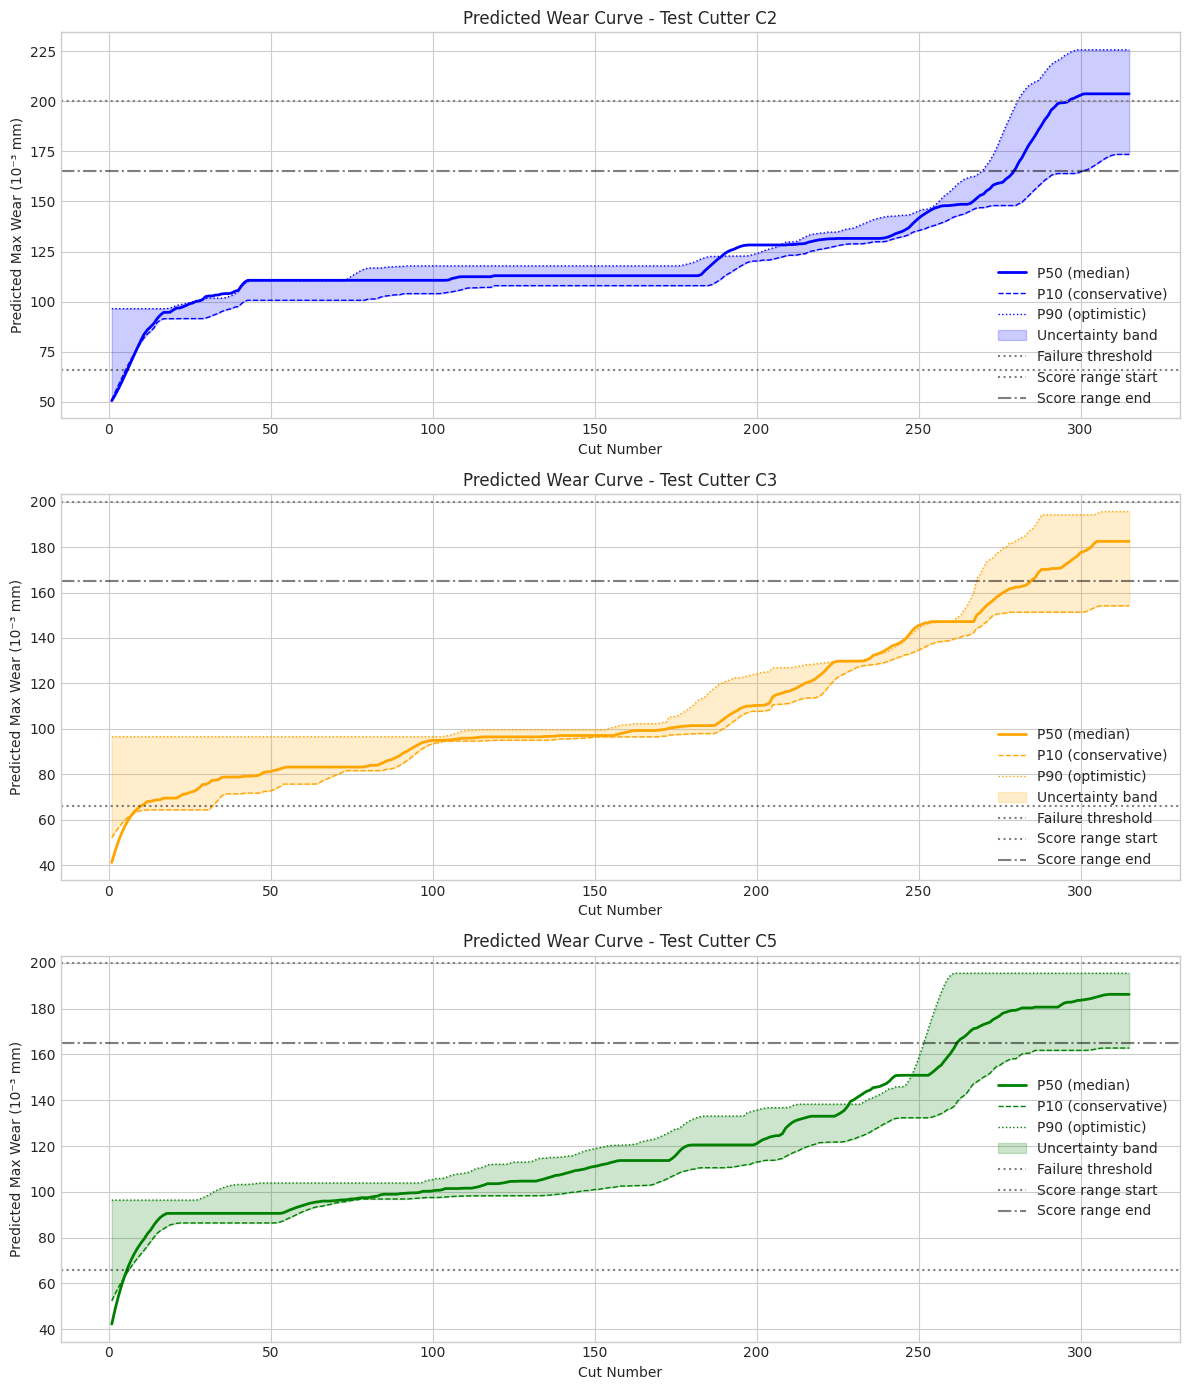

Plot saved


In [18]:
# Plot predicted wear curves for test cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

test_cutters = ['c2', 'c3', 'c5']
cuts_list = [cuts_c2, cuts_c3, cuts_c5]
pred_list = [pred_c2, pred_c3, pred_c5]
colors = {'c2': 'blue', 'c3': 'orange', 'c5': 'green'}

for ax, cutter, cuts, preds in zip(axes, test_cutters, cuts_list, pred_list):
    ax.plot(cuts, preds['P50'], color=colors[cutter], 
            linewidth=2, label='P50 (median)')
    ax.plot(cuts, preds['P10'], color=colors[cutter], 
            linewidth=1, linestyle='--', label='P10 (conservative)')
    ax.plot(cuts, preds['P90'], color=colors[cutter], 
            linewidth=1, linestyle=':', label='P90 (optimistic)')
    ax.fill_between(cuts, preds['P10'], preds['P90'], 
                    alpha=0.2, color=colors[cutter], label='Uncertainty band')
    ax.axhline(y=200, color='gray', linestyle=':', label='Failure threshold')
    ax.axhline(y=66, color='black', linestyle=':', alpha=0.5, label='Score range start')
    ax.axhline(y=165, color='black', linestyle='-.', alpha=0.5, label='Score range end')
    ax.set_title(f'Predicted Wear Curve - Test Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Predicted Max Wear (10⁻³ mm)')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/test_cutter_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [19]:
# Generate final challenge submission
submission_rows = []

for cutter, cuts, preds in [('c2', cuts_c2, pred_c2),
                              ('c3', cuts_c3, pred_c3),
                              ('c5', cuts_c5, pred_c5)]:
    safe_cuts = predict_safe_cuts(preds['P10'], cuts, wear_thresholds)
    
    for W, safe_cut in zip(wear_thresholds, safe_cuts):
        submission_rows.append({
            'cutter': cutter,
            'wear_threshold': W,
            'estimated_safe_cuts': int(safe_cut)
        })

submission_df = pd.DataFrame(submission_rows)

print("Challenge submission generated")
print(f"Shape: {submission_df.shape}")
print(f"\nSample predictions for C2:")
print(submission_df[submission_df['cutter']=='c2'].head(10))

Challenge submission generated
Shape: (300, 3)

Sample predictions for C2:
  cutter  wear_threshold  estimated_safe_cuts
0     c2              66                    6
1     c2              67                    6
2     c2              68                    6
3     c2              69                    7
4     c2              70                    7
5     c2              71                    7
6     c2              72                    8
7     c2              73                    8
8     c2              74                    8
9     c2              75                    9


In [20]:
# Save submission
submission_df.to_csv('/home/jupyter/submission_data_driven.csv', index=False)
submission_df.to_csv('gcs://phm2010-data-temilola/processed/submission_data_driven.csv', index=False)

# Save test cutter features
test_c2.to_csv('/home/jupyter/test_c2_features.csv', index=False)
test_c3.to_csv('/home/jupyter/test_c3_features.csv', index=False)
test_c5.to_csv('/home/jupyter/test_c5_features.csv', index=False)

test_c2.to_csv('gcs://phm2010-data-temilola/processed/test_c2_features.csv', index=False)
test_c3.to_csv('gcs://phm2010-data-temilola/processed/test_c3_features.csv', index=False)
test_c5.to_csv('gcs://phm2010-data-temilola/processed/test_c5_features.csv', index=False)

# Upload plots
!gsutil -m cp -r /home/jupyter/plots/* gs://phm2010-data-temilola/plots/

print("All outputs saved")

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Copying file:///home/jupyter/plots/all_cutters_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/c1_wear_progression.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/correlation_heatmap.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/features_vs_wear.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/gb_smoothed_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/model_comparison.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/sample_sensor_signals.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/quantile_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/gb_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/physics_predictions.png [Content-Type=image/png]...
Copying file:///home/jupyter/plots/test_cutter_predictions.png [Content-Type=image/png]...
- [11/11 files][  3.4 MiB/  3.4 Mi